In [1]:
import pandas as pd

rates = pd.read_csv("../user_movie_rates.csv")
users = pd.read_csv("../users.csv")
movies = pd.read_csv("../movies.csv")

age_groups = pd.read_csv("../age_groups.csv")
occupations = pd.read_csv("../occupations.csv")

movie_genres = pd.read_csv("../movie_genres.csv")
genres = pd.read_csv("../genres.csv")

movie_actors = pd.read_csv("../movie_actors.csv")
actors = pd.read_csv("../actors.csv")

movie_directors = pd.read_csv("../movie_directors.csv")
directors = pd.read_csv("../directors.csv")

movie_countries = pd.read_csv("../movie_countries.csv")
countries = pd.read_csv("../countries.csv")

movie_tag = pd.read_csv("../movie_tag.csv")
tags = pd.read_csv("../tags.csv")

mpaa_rates = pd.read_csv("../mpaa_rates.csv")

print("rates:", rates.shape, rates.columns.tolist())
print("users:", users.shape, users.columns.tolist())
print("movies:", movies.shape, movies.columns.tolist())

print("age_groups:", age_groups.shape, age_groups.columns.tolist())
print("occupations:", occupations.shape, occupations.columns.tolist())

print("movie_genres:", movie_genres.shape, movie_genres.columns.tolist())
print("genres:", genres.shape, genres.columns.tolist())

print("movie_actors:", movie_actors.shape, movie_actors.columns.tolist())
print("actors:", actors.shape, actors.columns.tolist())

print("movie_directors:", movie_directors.shape, movie_directors.columns.tolist())
print("directors:", directors.shape, directors.columns.tolist())

print("movie_countries:", movie_countries.shape, movie_countries.columns.tolist())
print("countries:", countries.shape, countries.columns.tolist())

print("movie_tag:", movie_tag.shape, movie_tag.columns.tolist())
print("tags:", tags.shape, tags.columns.tolist())

print("mpaa_rates:", mpaa_rates.shape, mpaa_rates.columns.tolist())

rates: (948367, 4) ['user_id', 'movie_id', 'rating', 'datetime']
users: (6040, 4) ['user_id', 'gender', 'occupation', 'age_group_id']
movies: (3433, 7) ['movie_id', 'title', 'year', 'rated', 'plot', 'imdb_rating', 'imdb_id']
age_groups: (7, 2) ['group_id', 'group_label']
occupations: (21, 2) ['occ_id', 'occ_name']
movie_genres: (6408, 2) ['movie_id', 'genre_id']
genres: (18, 2) ['genre_id', 'name']
movie_actors: (10285, 2) ['movie_id', 'actor_id']
actors: (4965, 2) ['actor_id', 'actor']
movie_directors: (3676, 2) ['movie_id', 'director_id']
directors: (1918, 2) ['director_id', 'director']
movie_countries: (4765, 2) ['movie_id', 'country_id']
countries: (84, 2) ['country_id', 'country']
movie_tag: (450912, 2) ['movie_id', 'tag_id']
tags: (48075, 2) ['tag_id', 'tag_name']
mpaa_rates: (5, 2) ['rate_id', 'rate_name']


In [2]:
user_features_base = users[["user_id", "gender", "occupation", "age_group_id"]].copy()
user_features_base.head()

,user_id,gender,occupation,age_group_id
0,1,F,11,1
1,2,M,17,7
2,3,M,16,3
3,4,M,8,5
4,5,M,21,3


In [3]:
movies.head()

,movie_id,title,year,rated,plot,imdb_rating,imdb_id
0,1,Toy Story,1995,4.0,A cowboy doll is profoundly jealous when a new...,8.3,tt0114709
1,2,Jumanji,1995,2.0,A magic board game summons jungle perils and a...,7.1,tt0113497
2,3,Grumpier Old Men,1995,3.0,Just as John and Max resolve to save their bel...,6.7,tt0113228
3,4,Waiting to Exhale,1995,1.0,"Based on Terry McMillan's novel, this film fol...",6.0,tt0114885
4,5,Father of the Bride Part II,1995,2.0,George Banks must deal not only with his daugh...,6.1,tt0113041


In [4]:
from common.feature_engineering import build_user_feature_tokens

user_feature_map = build_user_feature_tokens(user_features_base)
list(user_feature_map.items())[:5]

[(1, ['age_group:1', 'gender:F', 'occupation:11']),
 (2, ['age_group:7', 'gender:M', 'occupation:17']),
 (3, ['age_group:3', 'gender:M', 'occupation:16']),
 (4, ['age_group:5', 'gender:M', 'occupation:8']),
 (5, ['age_group:3', 'gender:M', 'occupation:21'])]

In [5]:
from common.feature_engineering import build_item_feature_tokens

movie_feature_map = build_item_feature_tokens(
    movie_genres=movie_genres,
    movie_actors=movie_actors,
    movie_directors=movie_directors,
    movie_countries=movie_countries,
)
list(movie_feature_map.items())[:5]

[(1,
  ['genre_id:3',
   'genre_id:4',
   'genre_id:5',
   'actor_id:1',
   'actor_id:2',
   'actor_id:3',
   'director_id:1',
   'country_id:1']),
 (2,
  ['genre_id:2',
   'genre_id:4',
   'genre_id:9',
   'actor_id:4',
   'actor_id:5',
   'actor_id:6',
   'director_id:2',
   'country_id:1']),
 (3,
  ['genre_id:5',
   'genre_id:14',
   'actor_id:7',
   'actor_id:8',
   'actor_id:9',
   'director_id:3',
   'country_id:1']),
 (4,
  ['genre_id:5',
   'genre_id:8',
   'actor_id:10',
   'actor_id:11',
   'actor_id:12',
   'director_id:4',
   'country_id:1']),
 (5,
  ['genre_id:5',
   'actor_id:13',
   'actor_id:14',
   'actor_id:15',
   'director_id:5',
   'country_id:1'])]

In [6]:
user_ids = list(user_feature_map.keys())
item_ids = list(movie_feature_map.keys())

In [7]:
all_user_features = sorted({
    token
    for tokens in user_feature_map.values()
    for token in tokens
})

all_item_features = sorted({
    token
    for tokens in movie_feature_map.values()
    for token in tokens
})

In [8]:
!pip install --upgrade pip

In [1]:
!pip install lightfm-next

zsh:1: command not found: pip


In [10]:
thresholds = [3.0, 4.0]
min_pos_values = [5, 10, 20]
LAST_N = [1, 2]

experiments = []

for threshold in thresholds:
    for min_pos in min_pos_values:
        experiments.append({
            "threshold": threshold,
            "min_pos": min_pos,
            "experiment": f"thr_{threshold}_minpos_{min_pos}"
        })

experiments

[{'threshold': 3.0, 'min_pos': 5, 'experiment': 'thr_3.0_minpos_5'},
 {'threshold': 3.0, 'min_pos': 10, 'experiment': 'thr_3.0_minpos_10'},
 {'threshold': 3.0, 'min_pos': 20, 'experiment': 'thr_3.0_minpos_20'},
 {'threshold': 4.0, 'min_pos': 5, 'experiment': 'thr_4.0_minpos_5'},
 {'threshold': 4.0, 'min_pos': 10, 'experiment': 'thr_4.0_minpos_10'},
 {'threshold': 4.0, 'min_pos': 20, 'experiment': 'thr_4.0_minpos_20'}]

In [13]:
from common.data_prep import build_edges, filter_users_min_pos
from common.split import time_split_last_n

splits = {}

for exp in experiments:
    for last_n in LAST_N:
        threshold = exp["threshold"]
        min_pos = exp["min_pos"]
        exp_name = exp["experiment"]

        edges = build_edges(
            data=rates,
            threshold=threshold,
            user_col="user_id",
            item_col="movie_id",
            rating_col="rating",
            time_col="datetime",
        )

        edges = filter_users_min_pos(
            data=edges,
            min_pos=min_pos,
            user_col="user_id",
        )

        train_df, test_df = time_split_last_n(
            data=edges,
            last_n=last_n,
            user_col="user_id",
            time_col="datetime",
        )

        splits[exp_name] = {
            "threshold": threshold,
            "min_pos": min_pos,
            "last_n": last_n,
            "train_df": train_df,
            "test_df": test_df,
        }

        print(
            exp_name,
            "| train:", train_df.shape,
            "| test:", test_df.shape,
            "| users:", train_df["user_id"].nunique(),
            "| items:", train_df["movie_id"].nunique(),
        )

thr_3.0_minpos_5 | train: (788185, 3) | test: (6038, 3) | users: 6038 | items: 3261
thr_3.0_minpos_5 | train: (782147, 3) | test: (12076, 3) | users: 6038 | items: 3259
thr_3.0_minpos_10 | train: (788150, 3) | test: (6033, 3) | users: 6033 | items: 3261
thr_3.0_minpos_10 | train: (782117, 3) | test: (12066, 3) | users: 6033 | items: 3259
thr_3.0_minpos_20 | train: (782542, 3) | test: (5673, 3) | users: 5673 | items: 3258
thr_3.0_minpos_20 | train: (776869, 3) | test: (11346, 3) | users: 5673 | items: 3256
thr_4.0_minpos_5 | train: (539595, 3) | test: (6033, 3) | users: 6033 | items: 3194
thr_4.0_minpos_5 | train: (533562, 3) | test: (12066, 3) | users: 6033 | items: 3190
thr_4.0_minpos_10 | train: (538960, 3) | test: (5937, 3) | users: 5937 | items: 3193
thr_4.0_minpos_10 | train: (533023, 3) | test: (11874, 3) | users: 5937 | items: 3189
thr_4.0_minpos_20 | train: (526821, 3) | test: (5083, 3) | users: 5083 | items: 3186
thr_4.0_minpos_20 | train: (521738, 3) | test: (10166, 3) | user

In [14]:
splits["thr_4.0_minpos_5"]["train_df"].head()

,user_id,movie_id,datetime
0,1,3186,2000-12-31 22:00:19+00:00
1,1,1270,2000-12-31 22:00:55+00:00
2,1,1721,2000-12-31 22:00:55+00:00
3,1,1022,2000-12-31 22:00:55+00:00
4,1,1836,2000-12-31 22:02:52+00:00


In [15]:
exp_name = "thr_4.0_minpos_5"

train_df = splits[exp_name]["train_df"]
test_df = splits[exp_name]["test_df"]

train_user_ids = sorted(train_df["user_id"].unique())
train_item_ids = sorted(train_df["movie_id"].unique())

user_feature_map_train = {
    user_id: user_feature_map[user_id]
    for user_id in train_user_ids
    if user_id in user_feature_map
}

movie_feature_map_train = {
    movie_id: movie_feature_map[movie_id]
    for movie_id in train_item_ids
    if movie_id in movie_feature_map
}


In [16]:
from lightfm.data import Dataset

dataset = Dataset()

dataset.fit(
    users=train_user_ids,
    items=train_item_ids,
    user_features=all_user_features,
    item_features=all_item_features,
)

/Users/alexandro/DataspellProjects/recommend-system/.venv/lib/python3.12/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


In [17]:
print(len(train_user_ids), len(train_item_ids))
print(len(all_user_features), len(all_item_features))

6033 3190
30 6985


In [18]:
train_pairs = list(zip(train_df["user_id"], train_df["movie_id"]))

interactions, weights = dataset.build_interactions(train_pairs)

In [19]:
user_feature_tuples = [
    (user_id, user_feature_map_train[user_id])
    for user_id in train_user_ids
]

user_features = dataset.build_user_features(user_feature_tuples)

In [20]:
item_feature_tuples = [
    (movie_id, movie_feature_map_train[movie_id])
    for movie_id in train_item_ids
]

item_features = dataset.build_item_features(item_feature_tuples)

In [21]:
print("interactions:", interactions.shape, interactions.nnz)
print("user_features:", user_features.shape)
print("item_features:", item_features.shape)

interactions: (6033, 3190) 533562
user_features: (6033, 6063)
item_features: (3190, 10175)


In [22]:
from lightfm import LightFM

model = LightFM(
    no_components=64,
    loss="warp",
    learning_rate=0.05,
    random_state=42
)

model.fit(
    interactions=interactions,
    user_features=user_features,
    item_features=item_features,
    epochs=20,
    num_threads=4,
    verbose=True
)

Epoch: 100%|██████████| 20/20 [00:25<00:00,  1.28s/it]


In [23]:
from common.eval import build_user_item_dict

ground_truth = build_user_item_dict(test_df)

In [24]:
user_id_map, user_feature_map_ds, item_id_map, item_feature_map_ds = dataset.mapping()

In [25]:
import numpy as np

K = 10
recommendations = {}

train_user_items = (
    train_df.groupby("user_id")["movie_id"]
    .apply(set)
    .to_dict()
)

all_item_ids = np.array(train_item_ids)

for user_id in ground_truth.keys():
    if user_id not in user_id_map:
        continue

    user_idx = user_id_map[user_id]

    scores = model.predict(
        user_ids=user_idx,
        item_ids=np.arange(len(train_item_ids)),
        user_features=user_features,
        item_features=item_features,
    )

    seen_items = train_user_items.get(user_id, set())

    candidate_pairs = [
        (item_id, score)
        for item_id, score in zip(all_item_ids, scores)
        if item_id not in seen_items
    ]

    candidate_pairs.sort(key=lambda x: x[1], reverse=True)

    recommendations[user_id] = [item_id for item_id, _ in candidate_pairs[:K]]

In [26]:
from common.eval import evaluate_ranking

metrics = evaluate_ranking(
    recommendations=recommendations,
    ground_truth=ground_truth,
    k=K,
)

metrics

{'precision': np.float64(0.013840543676446212),
 'recall': np.float64(0.06920271838223106),
 'map': np.float64(0.025167498072769082),
 'ndcg': np.float64(0.042094806616764256),
 'mrr': np.float64(0.04526131409522757),
 'hitrate': np.float64(0.12630532073595227)}

In [26]:
thresholds = [3.0, 4.0]
min_pos_values = [5, 10, 20]

LAST_N = 1
K = 10
NUM_THREADS = 8

NO_COMPONENTS = [64]
EPOCHS_LIST = [50, 80]
LEARNING_RATES = [0.01, 0.05]
LOSSES = ["warp", "bpr"]

experiments = []

for threshold in thresholds:
    for min_pos in min_pos_values:
        experiments.append({
            "threshold": threshold,
            "min_pos": min_pos,
            "experiment": f"thr_{threshold}_minpos_{min_pos}"
        })

experiments

[{'threshold': 3.0, 'min_pos': 5, 'experiment': 'thr_3.0_minpos_5'},
 {'threshold': 3.0, 'min_pos': 20, 'experiment': 'thr_3.0_minpos_20'},
 {'threshold': 4.0, 'min_pos': 5, 'experiment': 'thr_4.0_minpos_5'},
 {'threshold': 4.0, 'min_pos': 20, 'experiment': 'thr_4.0_minpos_20'}]

In [28]:
results = []

for exp in experiments:
    threshold = exp["threshold"]
    min_pos = exp["min_pos"]
    exp_name = exp["experiment"]

    print(f"\n{'=' * 80}")
    print(f"EXPERIMENT: {exp_name}")
    print(f"{'=' * 80}")

    # 1. Positive interactions
    edges = build_edges(
        data=rates,
        threshold=threshold,
        user_col="user_id",
        item_col="movie_id",
        rating_col="rating",
        time_col="datetime",
    )

    edges = filter_users_min_pos(
        data=edges,
        min_pos=min_pos,
        user_col="user_id",
    )

    # 2. Train / test split
    train_df, test_df = time_split_last_n(
        data=edges,
        last_n=LAST_N,
        user_col="user_id",
        time_col="datetime",
    )

    print(
        f"train={train_df.shape}, "
        f"test={test_df.shape}, "
        f"users={train_df['user_id'].nunique()}, "
        f"items={train_df['movie_id'].nunique()}"
    )

    # 3. Users/items from train only
    train_user_ids = sorted(train_df["user_id"].unique())
    train_item_ids = sorted(train_df["movie_id"].unique())

    # 4. Filter user/item feature maps for current train
    user_feature_map_train = {
        user_id: user_feature_map[user_id]
        for user_id in train_user_ids
        if user_id in user_feature_map
    }

    movie_feature_map_train = {
        movie_id: movie_feature_map[movie_id]
        for movie_id in train_item_ids
        if movie_id in movie_feature_map
    }

    # 5. Collect all feature tokens
    all_user_features = sorted({
        token
        for tokens in user_feature_map_train.values()
        for token in tokens
    })

    all_item_features = sorted({
        token
        for tokens in movie_feature_map_train.values()
        for token in tokens
    })

    # 6. Dataset
    dataset = Dataset()
    dataset.fit(
        users=train_user_ids,
        items=train_item_ids,
        user_features=all_user_features,
        item_features=all_item_features,
    )

    # 7. Interactions
    train_pairs = list(zip(train_df["user_id"], train_df["movie_id"]))
    interactions, weights = dataset.build_interactions(train_pairs)

    # 8. User features matrix
    user_feature_tuples = [
        (user_id, user_feature_map_train[user_id])
        for user_id in train_user_ids
    ]
    user_features = dataset.build_user_features(user_feature_tuples)

    # 9. Item features matrix
    item_feature_tuples = [
        (movie_id, movie_feature_map_train[movie_id])
        for movie_id in train_item_ids
    ]
    item_features = dataset.build_item_features(item_feature_tuples)

    print(
        f"interactions={interactions.shape}, nnz={interactions.nnz}, "
        f"user_features={user_features.shape}, item_features={item_features.shape}"
    )

    # 10. Ground truth
    test_df_eval = test_df[test_df["movie_id"].isin(train_item_ids)].copy()
    ground_truth = build_user_item_dict(test_df_eval)

    # 11. Seen items in train
    train_user_items = (
        train_df.groupby("user_id")["movie_id"]
        .apply(set)
        .to_dict()
    )

    # 12. Grid search over LightFM params
    for no_components in NO_COMPONENTS:
        for epochs in EPOCHS_LIST:
            for lr in LEARNING_RATES:
                for loss in LOSSES:
                    print(
                        f"  -> no_components={no_components}, "
                        f"epochs={epochs}, lr={lr}, loss={loss}"
                    )

                    model = LightFM(
                        no_components=no_components,
                        loss=loss,
                        learning_rate=lr,
                        random_state=42,
                    )

                    model.fit(
                        interactions=interactions,
                        user_features=user_features,
                        item_features=item_features,
                        epochs=epochs,
                        num_threads=NUM_THREADS,
                        verbose=True,
                    )

                    # Mapping from Dataset
                    user_id_map, user_feature_map_ds, item_id_map, item_feature_map_ds = dataset.mapping()

                    all_item_ids = np.array(train_item_ids)
                    recommendations = {}

                    for user_id in ground_truth.keys():
                        if user_id not in user_id_map:
                            continue

                        user_idx = user_id_map[user_id]

                        scores = model.predict(
                            user_ids=user_idx,
                            item_ids=np.arange(len(train_item_ids)),
                            user_features=user_features,
                            item_features=item_features,
                        )

                        seen_items = train_user_items.get(user_id, set())

                        candidate_pairs = [
                            (item_id, score)
                            for item_id, score in zip(all_item_ids, scores)
                            if item_id not in seen_items
                        ]

                        candidate_pairs.sort(key=lambda x: x[1], reverse=True)
                        recommendations[user_id] = [item_id for item_id, _ in candidate_pairs[:K]]

                    metrics = evaluate_ranking(
                        recommendations=recommendations,
                        ground_truth=ground_truth,
                        k=K,
                    )

                    row = {
                        "experiment": exp_name,
                        "threshold": threshold,
                        "min_pos": min_pos,
                        "last_n": LAST_N,
                        "k": K,
                        "precision": metrics["precision"],
                        "recall": metrics["recall"],
                        "map": metrics["map"],
                        "ndcg": metrics["ndcg"],
                        "mrr": metrics["mrr"],
                        "hitrate": metrics["hitrate"],
                        "train_edges": len(train_df),
                        "test_edges": len(test_df_eval),
                        "n_users": len(train_user_ids),
                        "n_items": len(train_item_ids),
                        "user_feature_dim": user_features.shape[1],
                        "item_feature_dim": item_features.shape[1],
                        "nnz": interactions.nnz,
                        "no_components": no_components,
                        "epochs": epochs,
                        "learning_rate": lr,
                        "loss": loss,
                    }

                    results.append(row)
                    print(f"metrics: {metrics}")


EXPERIMENT: thr_3.0_minpos_5
train=(788185, 3), test=(6038, 3), users=6038, items=3261
interactions=(6038, 3261), nnz=788185, user_features=(6038, 6068), item_features=(3261, 9761)
  -> no_components=64, epochs=50, lr=0.01, loss=warp


Epoch: 100%|██████████| 50/50 [01:41<00:00,  2.03s/it]


     metrics: {'precision': np.float64(0.0044739022369511185), 'recall': np.float64(0.04473902236951118), 'map': np.float64(0.015476124722189346), 'ndcg': np.float64(0.02220740628150942), 'mrr': np.float64(0.015476124722189346), 'hitrate': np.float64(0.04473902236951118)}
  -> no_components=64, epochs=50, lr=0.01, loss=bpr


Epoch: 100%|██████████| 50/50 [02:01<00:00,  2.42s/it]


     metrics: {'precision': np.float64(0.003993371996685998), 'recall': np.float64(0.03993371996685998), 'map': np.float64(0.014600084165121447), 'ndcg': np.float64(0.020408821689636755), 'mrr': np.float64(0.014600084165121447), 'hitrate': np.float64(0.03993371996685998)}
  -> no_components=64, epochs=50, lr=0.05, loss=warp


...

     metrics: {'precision': np.float64(0.0037598425196850396), 'recall': np.float64(0.037598425196850395), 'map': np.float64(0.013902637170353708), 'ndcg': np.float64(0.019381981344201858), 'mrr': np.float64(0.013902637170353708), 'hitrate': np.float64(0.037598425196850395)}
  -> no_components=64, epochs=80, lr=0.05, loss=warp


Epoch: 100%|██████████| 80/80 [01:31<00:00,  1.14s/it]


     metrics: {'precision': np.float64(0.007185039370078742), 'recall': np.float64(0.0718503937007874), 'map': np.float64(0.025098268966379202), 'ndcg': np.float64(0.03583907174829721), 'mrr': np.float64(0.025098268966379202), 'hitrate': np.float64(0.0718503937007874)}
  -> no_components=64, epochs=80, lr=0.05, loss=bpr


Epoch: 100%|██████████| 80/80 [02:07<00:00,  1.60s/it]


     metrics: {'precision': np.float64(0.006122047244094489), 'recall': np.float64(0.06122047244094488), 'map': np.float64(0.022527652793400826), 'ndcg': np.float64(0.031496460934881766), 'mrr': np.float64(0.022527652793400826), 'hitrate': np.float64(0.06122047244094488)}


In [29]:
lightfm_results_df = pd.DataFrame(results)
lightfm_results_df.sort_values(["recall", "ndcg"], ascending=False)

,experiment,threshold,min_pos,last_n,k,precision,recall,map,ndcg,mrr,...,test_edges,n_users,n_items,user_feature_dim,item_feature_dim,nnz,no_components,epochs,learning_rate,loss
22,thr_4.0_minpos_5,4.0,5,1,10,0.007728,0.077280,0.028200,0.039550,0.028200,...,6030,6033,3194,6063,9535,539595,64,80,0.05,warp
18,thr_4.0_minpos_5,4.0,5,1,10,0.007645,0.076451,0.028159,0.039329,0.028159,...,6030,6033,3194,6063,9535,539595,64,50,0.05,warp
6,thr_3.0_minpos_5,3.0,5,1,10,0.007490,0.074896,0.026985,0.038027,0.026985,...,6035,6038,3261,6068,9761,788185,64,80,0.05,warp
2,thr_3.0_minpos_5,3.0,5,1,10,0.007374,0.073737,0.026498,0.037422,0.026498,...,6035,6038,3261,6068,9761,788185,64,50,0.05,warp
14,thr_3.0_minpos_20,3.0,20,1,10,0.007231,0.072310,0.026258,0.036888,0.026258,...,5670,5673,3258,5703,9751,782542,64,80,0.05,warp
30,thr_4.0_minpos_20,4.0,20,1,10,0.007185,0.071850,0.025098,0.035839,0.025098,...,5080,5083,3186,5113,9506,526821,64,80,0.05,warp
26,thr_4.0_minpos_20,4.0,20,1,10,0.006988,0.069882,0.024193,0.034772,0.024193,...,5080,5083,3186,5113,9506,526821,64,50,0.05,warp
10,thr_3.0_minpos_20,3.0,20,1,10,0.006878,0.068783,0.024940,0.035102,0.024940,...,5670,5673,3258,5703,9751,782542,64,50,0.05,warp
7,thr_3.0_minpos_5,3.0,5,1,10,0.006694,0.066943,0.023278,0.033330,0.023278,...,6035,6038,3261,6068,9761,788185,64,80,0.05,bpr
23,thr_4.0_minpos_5,4.0,5,1,10,0.006683,0.066833,0.024600,0.034376,0.024600,...,6030,6033,3194,6063,9535,539595,64,80,0.05,bpr


In [30]:
df = lightfm_results_df.copy()

df["threshold"] = df["experiment"].str.extract(r"thr_(\d+\.\d+)").astype(float)
df["min_pos"] = df["experiment"].str.extract(r"minpos_(\d+)").astype(int)

numeric_cols = [
    "precision", "recall", "map", "ndcg", "mrr", "hitrate",
    "train_edges", "test_edges", "n_users", "n_items",
    "user_feature_dim", "item_feature_dim", "nnz",
    "last_n", "k", "no_components", "epochs", "learning_rate"
]

for c in numeric_cols:
    df[c] = df[c].astype(float)

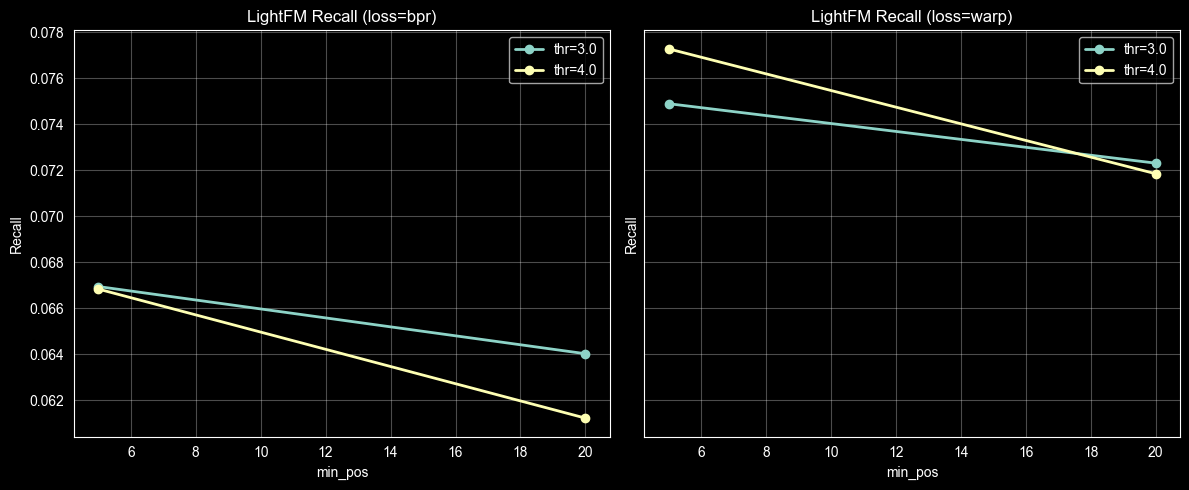

In [31]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, loss in zip(axes, sorted(df["loss"].unique())):
    subset = df[df["loss"] == loss]

    for thr in sorted(subset["threshold"].unique()):
        tmp = (
            subset[subset["threshold"] == thr]
            .groupby("min_pos", as_index=False)["recall"]
            .max()
            .sort_values("min_pos")
        )

        ax.plot(
            tmp["min_pos"],
            tmp["recall"],
            marker="o",
            linewidth=2,
            label=f"thr={thr}"
        )

    ax.set_title(f"LightFM Recall (loss={loss})")
    ax.set_xlabel("min_pos")
    ax.set_ylabel("Recall")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

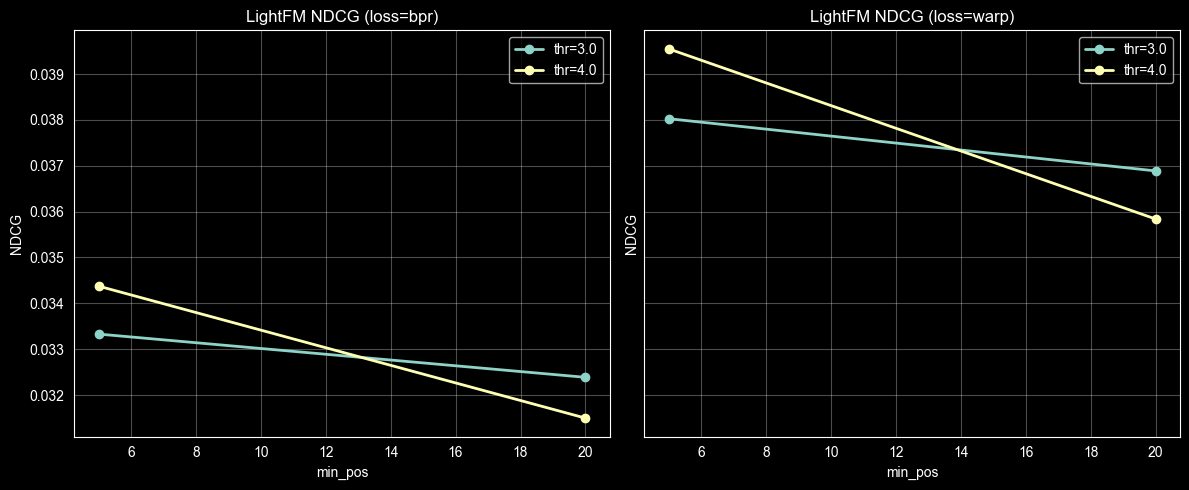

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, loss in zip(axes, sorted(df["loss"].unique())):
    subset = df[df["loss"] == loss]

    for thr in sorted(subset["threshold"].unique()):
        tmp = (
            subset[subset["threshold"] == thr]
            .groupby("min_pos", as_index=False)["ndcg"]
            .max()
            .sort_values("min_pos")
        )

        ax.plot(
            tmp["min_pos"],
            tmp["ndcg"],
            marker="o",
            linewidth=2,
            label=f"thr={thr}"
        )

    ax.set_title(f"LightFM NDCG (loss={loss})")
    ax.set_xlabel("min_pos")
    ax.set_ylabel("NDCG")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

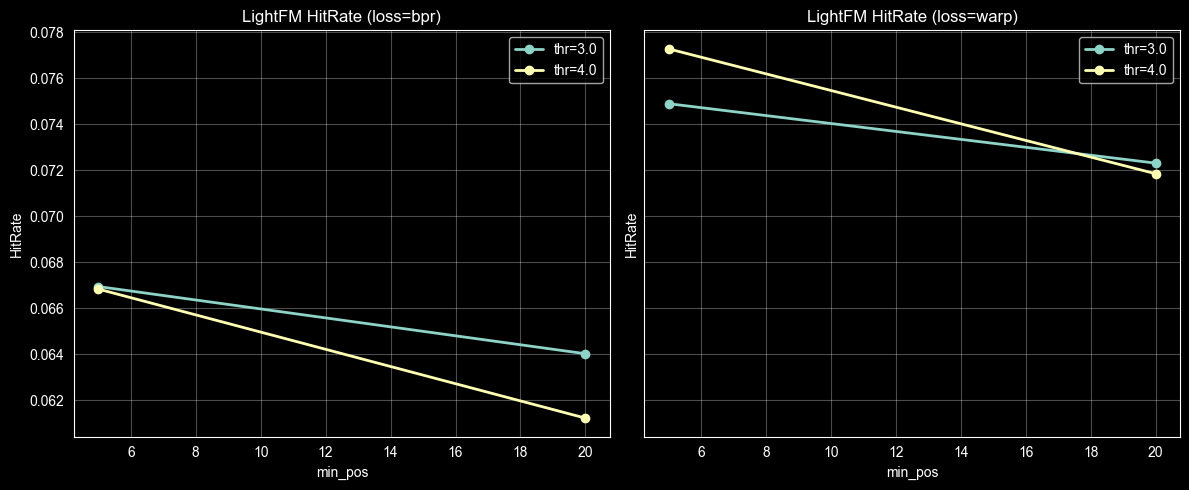

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, loss in zip(axes, sorted(df["loss"].unique())):
    subset = df[df["loss"] == loss]

    for thr in sorted(subset["threshold"].unique()):
        tmp = (
            subset[subset["threshold"] == thr]
            .groupby("min_pos", as_index=False)["hitrate"]
            .max()
            .sort_values("min_pos")
        )

        ax.plot(
            tmp["min_pos"],
            tmp["hitrate"],
            marker="o",
            linewidth=2,
            label=f"thr={thr}"
        )

    ax.set_title(f"LightFM HitRate (loss={loss})")
    ax.set_xlabel("min_pos")
    ax.set_ylabel("HitRate")
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

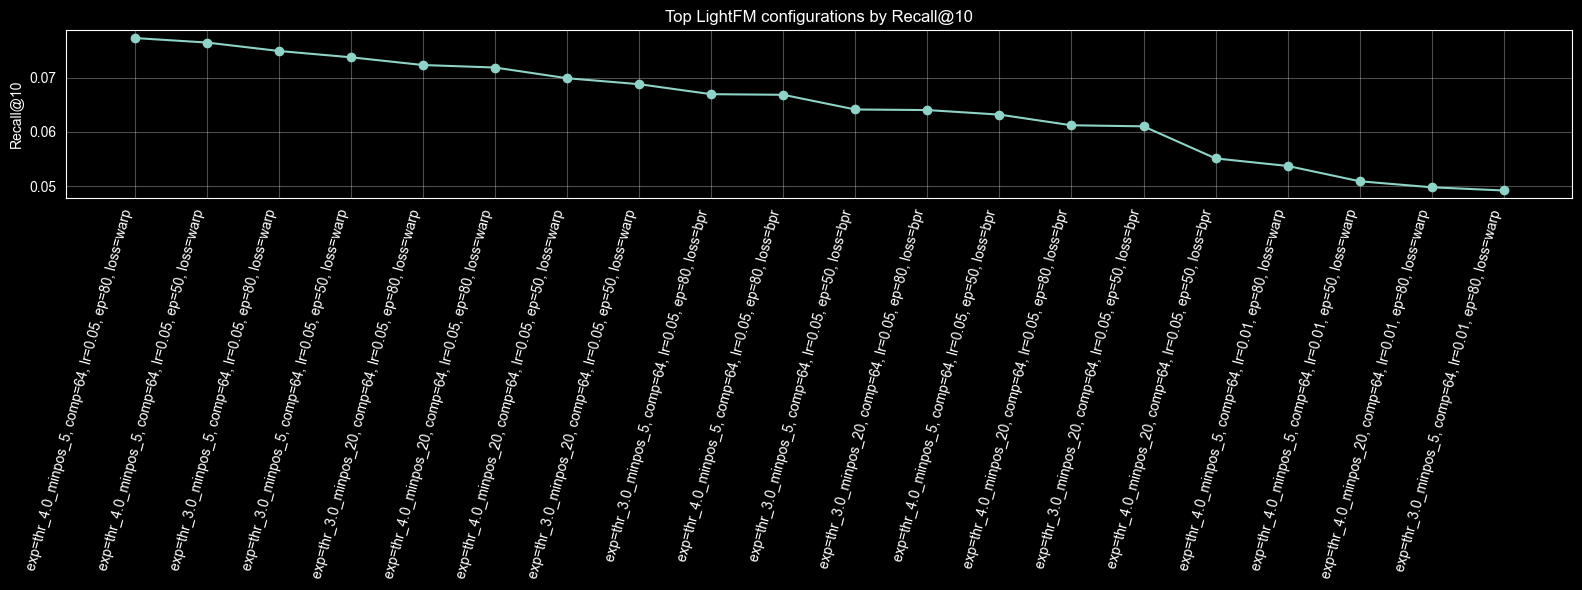

In [35]:
top_n = 20

top_df = df.sort_values(["recall", "ndcg"], ascending=False).head(top_n).copy()

top_df["label"] = (
    "exp=" + top_df["experiment"]
    + ", comp=" + top_df["no_components"].astype(int).astype(str)
    + ", lr=" + top_df["learning_rate"].astype(str)
    + ", ep=" + top_df["epochs"].astype(int).astype(str)
    + ", loss=" + top_df["loss"].astype(str)
)

plt.figure(figsize=(16, 6))
plt.plot(top_df["label"], top_df["recall"], marker="o")
plt.xticks(rotation=75, ha="right")
plt.ylabel("Recall@10")
plt.title("Top LightFM configurations by Recall@10")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

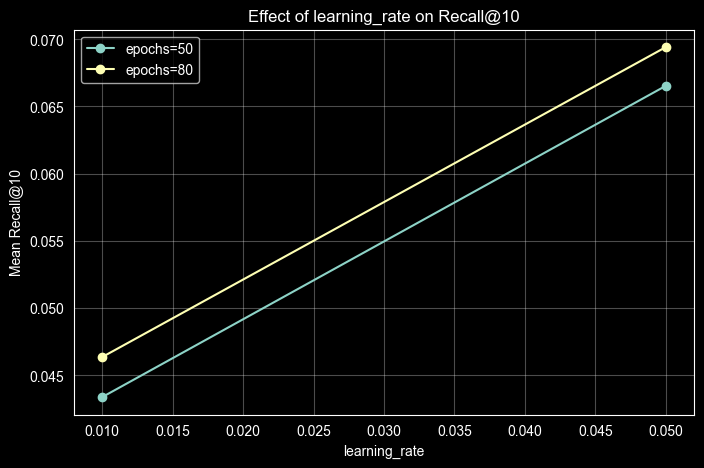

In [36]:
plt.figure(figsize=(8, 5))

for epochs in sorted(df["epochs"].unique()):
    tmp = (
        df.groupby(["learning_rate", "epochs"], as_index=False)["recall"]
          .mean()
    )
    tmp = tmp[tmp["epochs"] == epochs].sort_values("learning_rate")

    plt.plot(
        tmp["learning_rate"],
        tmp["recall"],
        marker="o",
        label=f"epochs={int(epochs)}"
    )

plt.xlabel("learning_rate")
plt.ylabel("Mean Recall@10")
plt.title("Effect of learning_rate on Recall@10")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [42]:
thresholds = [3.0, 4.0]
min_pos_values = [5, 10, 20]

LAST_N = [1, 2]
K = [5, 10, 20]
NUM_THREADS = 8

NO_COMPONENTS = [64]
EPOCHS_LIST = [80, 120, 160]
LEARNING_RATES = 0.1
LOSSES = ["warp"]

experiments = []

for threshold in thresholds:
    for min_pos in min_pos_values:
        for last_n in LAST_N:
            experiments.append({
                "threshold": threshold,
                "min_pos": min_pos,
                "last_n": last_n,
                "experiment": f"thr_{threshold}_minpos_{min_pos}_lastn_{last_n}"
            })

experiments

[{'threshold': 3.0,
  'min_pos': 5,
  'last_n': 1,
  'experiment': 'thr_3.0_minpos_5_lastn_1'},
 {'threshold': 3.0,
  'min_pos': 5,
  'last_n': 2,
  'experiment': 'thr_3.0_minpos_5_lastn_2'},
 {'threshold': 3.0,
  'min_pos': 10,
  'last_n': 1,
  'experiment': 'thr_3.0_minpos_10_lastn_1'},
 {'threshold': 3.0,
  'min_pos': 10,
  'last_n': 2,
  'experiment': 'thr_3.0_minpos_10_lastn_2'},
 {'threshold': 3.0,
  'min_pos': 20,
  'last_n': 1,
  'experiment': 'thr_3.0_minpos_20_lastn_1'},
 {'threshold': 3.0,
  'min_pos': 20,
  'last_n': 2,
  'experiment': 'thr_3.0_minpos_20_lastn_2'},
 {'threshold': 4.0,
  'min_pos': 5,
  'last_n': 1,
  'experiment': 'thr_4.0_minpos_5_lastn_1'},
 {'threshold': 4.0,
  'min_pos': 5,
  'last_n': 2,
  'experiment': 'thr_4.0_minpos_5_lastn_2'},
 {'threshold': 4.0,
  'min_pos': 10,
  'last_n': 1,
  'experiment': 'thr_4.0_minpos_10_lastn_1'},
 {'threshold': 4.0,
  'min_pos': 10,
  'last_n': 2,
  'experiment': 'thr_4.0_minpos_10_lastn_2'},
 {'threshold': 4.0,
  'min_p

In [43]:
results = []

for exp in experiments:
    threshold = exp["threshold"]
    min_pos = exp["min_pos"]
    exp_name = exp["experiment"]
    last_n = exp["last_n"]

    print(f"\n{'=' * 80}")
    print(f"EXPERIMENT: {exp_name}")
    print(f"{'=' * 80}")

    # 1. Positive interactions
    edges = build_edges(
        data=rates,
        threshold=threshold,
        user_col="user_id",
        item_col="movie_id",
        rating_col="rating",
        time_col="datetime",
    )

    edges = filter_users_min_pos(
        data=edges,
        min_pos=min_pos,
        user_col="user_id",
    )

    # 2. Train / test split
    train_df, test_df = time_split_last_n(
        data=edges,
        last_n=last_n,
        user_col="user_id",
        time_col="datetime",
    )

    print(
        f"train={train_df.shape}, "
        f"test={test_df.shape}, "
        f"users={train_df['user_id'].nunique()}, "
        f"items={train_df['movie_id'].nunique()}"
    )

    # 3. Users/items from train only
    train_user_ids = sorted(train_df["user_id"].unique())
    train_item_ids = sorted(train_df["movie_id"].unique())

    # 4. Filter user/item feature maps for current train
    user_feature_map_train = {
        user_id: user_feature_map[user_id]
        for user_id in train_user_ids
        if user_id in user_feature_map
    }

    movie_feature_map_train = {
        movie_id: movie_feature_map[movie_id]
        for movie_id in train_item_ids
        if movie_id in movie_feature_map
    }

    # 5. Collect all feature tokens
    all_user_features = sorted({
        token
        for tokens in user_feature_map_train.values()
        for token in tokens
    })

    all_item_features = sorted({
        token
        for tokens in movie_feature_map_train.values()
        for token in tokens
    })

    # 6. Dataset
    dataset = Dataset()
    dataset.fit(
        users=train_user_ids,
        items=train_item_ids,
        user_features=all_user_features,
        item_features=all_item_features,
    )

    # 7. Interactions
    train_pairs = list(zip(train_df["user_id"], train_df["movie_id"]))
    interactions, weights = dataset.build_interactions(train_pairs)

    # 8. User features matrix
    user_feature_tuples = [
        (user_id, user_feature_map_train[user_id])
        for user_id in train_user_ids
    ]
    user_features = dataset.build_user_features(user_feature_tuples)

    # 9. Item features matrix
    item_feature_tuples = [
        (movie_id, movie_feature_map_train[movie_id])
        for movie_id in train_item_ids
    ]
    item_features = dataset.build_item_features(item_feature_tuples)

    print(
        f"interactions={interactions.shape}, nnz={interactions.nnz}, "
        f"user_features={user_features.shape}, item_features={item_features.shape}"
    )

    # 10. Ground truth
    test_df_eval = test_df[test_df["movie_id"].isin(train_item_ids)].copy()
    ground_truth = build_user_item_dict(test_df_eval)

    # 11. Seen items in train
    train_user_items = (
        train_df.groupby("user_id")["movie_id"]
        .apply(set)
        .to_dict()
    )

    # 12. Grid search over LightFM params
    for no_components in NO_COMPONENTS:
        for epochs in EPOCHS_LIST:
            for k in K:
                for loss in LOSSES:
                    print(
                        f"  -> no_components={no_components}, "
                        f"epochs={epochs}, lr={LEARNING_RATES}, loss={loss}"
                    )

                    model = LightFM(
                        no_components=no_components,
                        loss=loss,
                        learning_rate=LEARNING_RATES,
                        random_state=42,
                    )

                    model.fit(
                        interactions=interactions,
                        user_features=user_features,
                        item_features=item_features,
                        epochs=epochs,
                        num_threads=NUM_THREADS,
                        verbose=True,
                    )

                    # Mapping from Dataset
                    user_id_map, user_feature_map_ds, item_id_map, item_feature_map_ds = dataset.mapping()

                    all_item_ids = np.array(train_item_ids)
                    recommendations = {}

                    for user_id in ground_truth.keys():
                        if user_id not in user_id_map:
                            continue

                        user_idx = user_id_map[user_id]

                        scores = model.predict(
                            user_ids=user_idx,
                            item_ids=np.arange(len(train_item_ids)),
                            user_features=user_features,
                            item_features=item_features,
                        )

                        seen_items = train_user_items.get(user_id, set())

                        candidate_pairs = [
                            (item_id, score)
                            for item_id, score in zip(all_item_ids, scores)
                            if item_id not in seen_items
                        ]

                        candidate_pairs.sort(key=lambda x: x[1], reverse=True)
                        recommendations[user_id] = [item_id for item_id, _ in candidate_pairs[:k]]

                    metrics = evaluate_ranking(
                        recommendations=recommendations,
                        ground_truth=ground_truth,
                        k=k,
                    )

                    row = {
                        "experiment": exp_name,
                        "threshold": threshold,
                        "min_pos": min_pos,
                        "last_n": last_n,
                        "k": k,
                        "precision": metrics["precision"],
                        "recall": metrics["recall"],
                        "map": metrics["map"],
                        "ndcg": metrics["ndcg"],
                        "mrr": metrics["mrr"],
                        "hitrate": metrics["hitrate"],
                        "train_edges": len(train_df),
                        "test_edges": len(test_df_eval),
                        "n_users": len(train_user_ids),
                        "n_items": len(train_item_ids),
                        "user_feature_dim": user_features.shape[1],
                        "item_feature_dim": item_features.shape[1],
                        "nnz": interactions.nnz,
                        "no_components": no_components,
                        "epochs": epochs,
                        "learning_rate": LEARNING_RATES,
                        "loss": loss,
                    }

                    results.append(row)
                    print(f"metrics: {metrics}")


EXPERIMENT: thr_3.0_minpos_5_lastn_1
train=(788185, 3), test=(6038, 3), users=6038, items=3261
interactions=(6038, 3261), nnz=788185, user_features=(6038, 6068), item_features=(3261, 9761)
  -> no_components=64, epochs=80, lr=0.1, loss=warp


Epoch: 100%|██████████| 80/80 [02:10<00:00,  1.63s/it]


metrics: {'precision': np.float64(0.009411764705882354), 'recall': np.float64(0.047058823529411764), 'map': np.float64(0.025468102734051364), 'ndcg': np.float64(0.03081293634793331), 'mrr': np.float64(0.025468102734051364), 'hitrate': np.float64(0.047058823529411764)}
  -> no_components=64, epochs=80, lr=0.1, loss=warp


Epoch: 100%|██████████| 80/80 [02:06<00:00,  1.58s/it]


metrics: {'precision': np.float64(0.008616404308202154), 'recall': np.float64(0.08616404308202154), 'map': np.float64(0.030455740981838744), 'ndcg': np.float64(0.043223194879260615), 'mrr': np.float64(0.030455740981838744), 'hitrate': np.float64(0.08616404308202154)}
  -> no_components=64, epochs=80, lr=0.1, loss=warp


...

metrics: {'precision': np.float64(0.01778477277198505), 'recall': np.float64(0.044461931929962624), 'map': np.float64(0.022993311036789296), 'ndcg': np.float64(0.03384424355974952), 'mrr': np.float64(0.04246507967735589), 'hitrate': np.float64(0.0832185717096203)}
  -> no_components=64, epochs=160, lr=0.1, loss=warp


Epoch: 100%|██████████| 160/160 [02:38<00:00,  1.01it/s]


metrics: {'precision': np.float64(0.016171552232933303), 'recall': np.float64(0.08085776116466653), 'map': np.float64(0.028281831127099668), 'ndcg': np.float64(0.048192797628862874), 'mrr': np.float64(0.05103886593656414), 'hitrate': np.float64(0.1483375959079284)}
  -> no_components=64, epochs=160, lr=0.1, loss=warp


Epoch: 100%|██████████| 160/160 [02:37<00:00,  1.01it/s]


metrics: {'precision': np.float64(0.013673027739523903), 'recall': np.float64(0.13673027739523902), 'map': np.float64(0.032584409414167015), 'ndcg': np.float64(0.06536715597832785), 'mrr': np.float64(0.05755680442253301), 'hitrate': np.float64(0.24414715719063546)}


In [44]:
results_df = pd.DataFrame(results)
results_df

,experiment,threshold,min_pos,last_n,k,precision,recall,map,ndcg,mrr,...,test_edges,n_users,n_items,user_feature_dim,item_feature_dim,nnz,no_components,epochs,learning_rate,loss
0,thr_3.0_minpos_5_lastn_1,3.0,5,1,5,0.009412,0.047059,0.025468,0.030813,0.025468,...,6035,6038,3261,6068,9761,788185,64,80,0.1,warp
1,thr_3.0_minpos_5_lastn_1,3.0,5,1,10,0.008616,0.086164,0.030456,0.043223,0.030456,...,6035,6038,3261,6068,9761,788185,64,80,0.1,warp
2,thr_3.0_minpos_5_lastn_1,3.0,5,1,20,0.007341,0.146810,0.034562,0.058430,0.034562,...,6035,6038,3261,6068,9761,788185,64,80,0.1,warp
3,thr_3.0_minpos_5_lastn_1,3.0,5,1,5,0.010008,0.050041,0.026040,0.031932,0.026040,...,6035,6038,3261,6068,9761,788185,64,120,0.1,warp
4,thr_3.0_minpos_5_lastn_1,3.0,5,1,10,0.008699,0.086993,0.030876,0.043784,0.030876,...,6035,6038,3261,6068,9761,788185,64,120,0.1,warp
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,thr_4.0_minpos_20_lastn_2,4.0,20,2,10,0.015935,0.079677,0.027694,0.047330,0.049930,...,10160,5083,3183,5113,9500,521738,64,120,0.1,warp
104,thr_4.0_minpos_20_lastn_2,4.0,20,2,20,0.013703,0.137124,0.032127,0.065004,0.056667,...,10160,5083,3183,5113,9500,521738,64,120,0.1,warp
105,thr_4.0_minpos_20_lastn_2,4.0,20,2,5,0.017785,0.044462,0.022993,0.033844,0.042465,...,10160,5083,3183,5113,9500,521738,64,160,0.1,warp
106,thr_4.0_minpos_20_lastn_2,4.0,20,2,10,0.016172,0.080858,0.028282,0.048193,0.051039,...,10160,5083,3183,5113,9500,521738,64,160,0.1,warp


In [45]:
max_recall_per_k = results_df.loc[
    results_df.groupby("k")["recall"].idxmax()
].sort_values("k")

max_recall_per_k

,experiment,threshold,min_pos,last_n,k,precision,recall,map,ndcg,mrr,...,test_edges,n_users,n_items,user_feature_dim,item_feature_dim,nnz,no_components,epochs,learning_rate,loss
75,thr_4.0_minpos_10_lastn_1,4.0,10,1,5,0.010280,0.051399,0.025051,0.031523,0.025051,...,5934,5937,3193,5967,9530,538960,64,120,0.1,warp
79,thr_4.0_minpos_10_lastn_1,4.0,10,1,10,0.009117,0.091170,0.030047,0.044031,0.030047,...,5934,5937,3193,5967,9530,538960,64,160,0.1,warp
59,thr_4.0_minpos_5_lastn_1,4.0,5,1,20,0.007985,0.159701,0.034809,0.061237,0.034809,...,6030,6033,3194,6063,9535,539595,64,120,0.1,warp


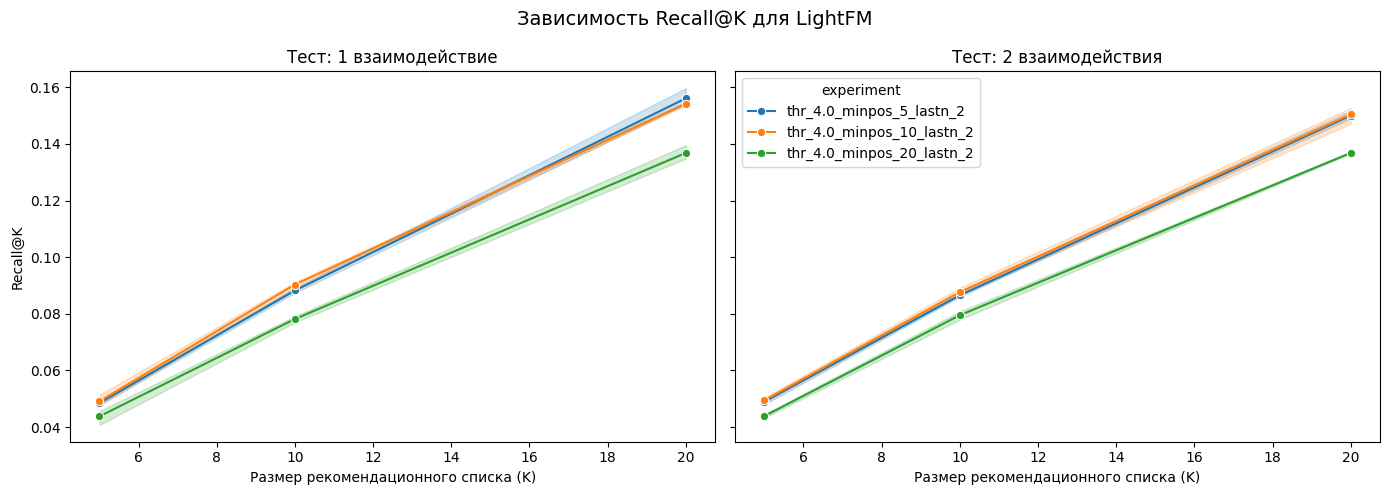

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# если нужно — можно отфильтровать конкретные эксперименты
# например:
df_filtered = results_df[results_df["experiment"].str.contains("thr_4")]

# создаем 2 графика
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# график для last_n = 1
sns.lineplot(
    data=df_filtered[df_filtered["last_n"] == 1],
    x="k",
    y="recall",
    hue="experiment",   # <-- вместо min_pos
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Тест: 1 взаимодействие")
axes[0].set_xlabel("Размер рекомендационного списка (K)")
axes[0].set_ylabel("Recall@K")

# график для last_n = 2
sns.lineplot(
    data=df_filtered[df_filtered["last_n"] == 2],
    x="k",
    y="recall",
    hue="experiment",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Тест: 2 взаимодействия")
axes[1].set_xlabel("Размер рекомендационного списка (K)")
axes[1].set_ylabel("")

# убираем дублирующую легенду
axes[0].get_legend().remove()

plt.suptitle("Зависимость Recall@K для LightFM", fontsize=14)

plt.tight_layout()
plt.show()

In [47]:
max_recall_per_k = results_df.loc[
    results_df.groupby("k")["ndcg"].idxmax()
].sort_values("k")

max_recall_per_k

,experiment,threshold,min_pos,last_n,k,precision,recall,map,ndcg,mrr,...,test_edges,n_users,n_items,user_feature_dim,item_feature_dim,nnz,no_components,epochs,learning_rate,loss
15,thr_3.0_minpos_5_lastn_2,3.0,5,2,5,0.020040,0.050182,0.026017,0.038556,0.049346,...,12071,6038,3259,6068,9753,782147,64,160,0.1,warp
34,thr_3.0_minpos_10_lastn_2,3.0,10,2,10,0.017819,0.089093,0.030644,0.053026,0.057214,...,12061,6033,3259,6063,9753,782117,64,160,0.1,warp
17,thr_3.0_minpos_5_lastn_2,3.0,5,2,20,0.015146,0.151623,0.036237,0.072797,0.065328,...,12071,6038,3259,6068,9753,782147,64,160,0.1,warp


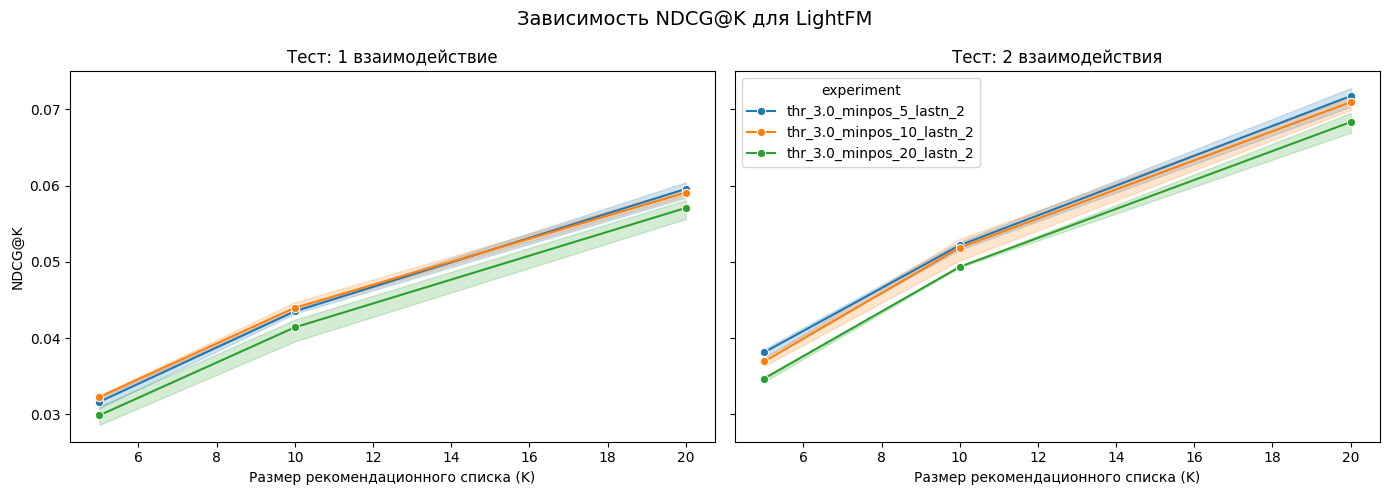

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# если нужно — можно отфильтровать конкретные эксперименты
# например:
df_filtered = results_df[results_df["experiment"].str.contains("thr_3")]

# создаем 2 графика
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# график для last_n = 1
sns.lineplot(
    data=df_filtered[df_filtered["last_n"] == 1],
    x="k",
    y="ndcg",
    hue="experiment",   # <-- вместо min_pos
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Тест: 1 взаимодействие")
axes[0].set_xlabel("Размер рекомендационного списка (K)")
axes[0].set_ylabel("NDCG@K")

# график для last_n = 2
sns.lineplot(
    data=df_filtered[df_filtered["last_n"] == 2],
    x="k",
    y="ndcg",
    hue="experiment",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Тест: 2 взаимодействия")
axes[1].set_xlabel("Размер рекомендационного списка (K)")
axes[1].set_ylabel("")

# убираем дублирующую легенду
axes[0].get_legend().remove()

plt.suptitle("Зависимость NDCG@K для LightFM", fontsize=14)

plt.tight_layout()
plt.show()

In [49]:
max_recall_per_k = results_df.loc[
    results_df.groupby("k")["hitrate"].idxmax()
].sort_values("k")

max_recall_per_k

,experiment,threshold,min_pos,last_n,k,precision,recall,map,ndcg,mrr,...,test_edges,n_users,n_items,user_feature_dim,item_feature_dim,nnz,no_components,epochs,learning_rate,loss
15,thr_3.0_minpos_5_lastn_2,3.0,5,2,5,0.020040,0.050182,0.026017,0.038556,0.049346,...,12071,6038,3259,6068,9753,782147,64,160,0.1,warp
34,thr_3.0_minpos_10_lastn_2,3.0,10,2,10,0.017819,0.089093,0.030644,0.053026,0.057214,...,12061,6033,3259,6063,9753,782117,64,160,0.1,warp
17,thr_3.0_minpos_5_lastn_2,3.0,5,2,20,0.015146,0.151623,0.036237,0.072797,0.065328,...,12071,6038,3259,6068,9753,782147,64,160,0.1,warp


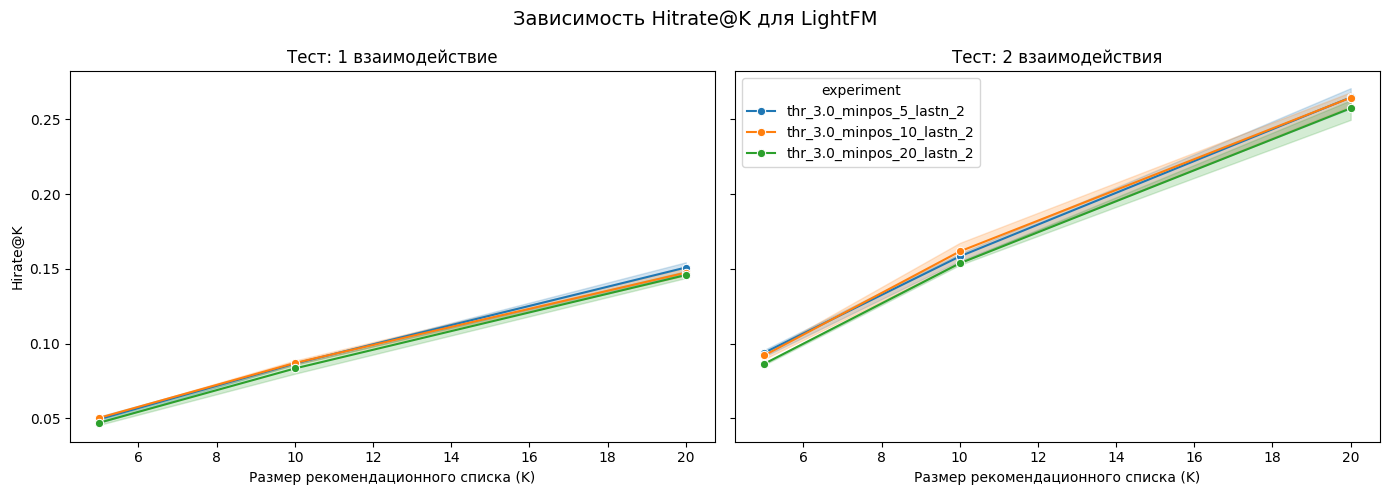

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# если нужно — можно отфильтровать конкретные эксперименты
# например:
df_filtered = results_df[results_df["experiment"].str.contains("thr_3")]

# создаем 2 графика
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# график для last_n = 1
sns.lineplot(
    data=df_filtered[df_filtered["last_n"] == 1],
    x="k",
    y="hitrate",
    hue="experiment",   # <-- вместо min_pos
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Тест: 1 взаимодействие")
axes[0].set_xlabel("Размер рекомендационного списка (K)")
axes[0].set_ylabel("Hirate@K")

# график для last_n = 2
sns.lineplot(
    data=df_filtered[df_filtered["last_n"] == 2],
    x="k",
    y="hitrate",
    hue="experiment",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Тест: 2 взаимодействия")
axes[1].set_xlabel("Размер рекомендационного списка (K)")
axes[1].set_ylabel("")

# убираем дублирующую легенду
axes[0].get_legend().remove()

plt.suptitle("Зависимость Hitrate@K для LightFM", fontsize=14)

plt.tight_layout()
plt.show()